# Z-Logit Credit Risk Modeling: Integration and Validation  
**Author:** Daniel Capitán Lobato  
**Date:** 2025-07-30  

This notebook documents the complete pipeline for integrating, cleaning, modeling, and validating a logistic regression model inspired by Altman’s Z-Score (Z-Logit), applied to corporate financial risk assessment. The aim is to develop a robust, auditable, and reproducible system, supporting consulting, benchmarking, and pricing decisions.

---

In [92]:
# ================ SETUP ================ #

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from scipy.stats import zscore
from sklearn.pipeline import make_pipeline

# Add the 'src/' folder to python path for custom modules
sys.path.append(os.path.abspath("../src"))

import importlib
import procesar_zscore
importlib.reload(procesar_zscore)

from procesar_zscore import (
    procesar_archivo, 
    transformar_a_formato_largo,
    validar_estructura,
    detectar_outliers_zscore,
    calcular_ratios_zlogit,
    winsorize_percentiles,
    winsorize_iqr,
    calcular_is_distressed,
    filtrar_no_financieras,
    categorizar_riesgo_sector,
    rating_altman
)

# Years included in the panel
years = [2019, 2020, 2021, 2022, 2023]

---

## 1. Data Loading and Initial Processing

Annual CSV files exported from S&P Capital IQ Pro are loaded and processed into a clean panel dataset.
Structure and consistency of columns are validated for each year before concatenation.

---

In [93]:
# ========== PROCESSING RAW FILES ==========

dfs = []
for year in years:
    file_path = f"../data/zscore_sample{year}.csv"
    df_year = procesar_archivo(file_path, year)
    print(f"{year}: DataFrame processed with shape {df_year.shape}")
    dfs.append(df_year)

# Validate column structure across years
validar_estructura(dfs)

2019: DataFrame processed with shape (19515, 20)
2020: DataFrame processed with shape (18771, 20)
2021: DataFrame processed with shape (18229, 20)
2022: DataFrame processed with shape (17458, 20)
2023: DataFrame processed with shape (16682, 20)
⚠️ Year 2020: different columns: ['IQ_AVG_BASIC_SHARES_OUT_2019', 'IQ_AVG_BASIC_SHARES_OUT_2020', 'IQ_EBIT_2019', 'IQ_EBIT_2020', 'IQ_INTEREST_EXP_2019', 'IQ_INTEREST_EXP_2020', 'IQ_RETAINED_EARNINGS_2019', 'IQ_RETAINED_EARNINGS_2020', 'IQ_TOTAL_ASSETS_2019', 'IQ_TOTAL_ASSETS_2020', 'IQ_TOTAL_CA_2019', 'IQ_TOTAL_CA_2020', 'IQ_TOTAL_CL_2019', 'IQ_TOTAL_CL_2020', 'IQ_TOTAL_DEBT_2019', 'IQ_TOTAL_DEBT_2020', 'IQ_TOTAL_LIAB_2019', 'IQ_TOTAL_LIAB_2020', 'IQ_TOTAL_REV_2019', 'IQ_TOTAL_REV_2020']
⚠️ Year 2021: different columns: ['IQ_AVG_BASIC_SHARES_OUT_2019', 'IQ_AVG_BASIC_SHARES_OUT_2021', 'IQ_EBIT_2019', 'IQ_EBIT_2021', 'IQ_INTEREST_EXP_2019', 'IQ_INTEREST_EXP_2021', 'IQ_RETAINED_EARNINGS_2019', 'IQ_RETAINED_EARNINGS_2021', 'IQ_TOTAL_ASSETS_2019', '

**Note:**  
If the validator reports different columns, check for any annual features with year suffixes (e.g., `IQ_TOTAL_ASSETS_2019`) and address these in the preprocessing function as needed.

In [94]:
# ========== CONCATENATE PANEL ==========

df_panel = pd.concat(dfs, axis=0).reset_index(drop=True)
print(f"Final panel shape: {df_panel.shape}")

Final panel shape: (90655, 60)


In [95]:
# Preview
display(df_panel.head())

,SP_ENTITY_NAME,SP_ENTITY_ID,SP_GEOGRAPHY,SP_COUNTRY_NAME,SP_COMPANY_TYPE,IQ_INDUSTRY_CLASSIFICATION,SP_COMPANY_STATUS,SP_YEAR_INCORPORATED,IQ_TOTAL_ASSETS_2019,IQ_TOTAL_REV_2019,...,IQ_TOTAL_ASSETS_2023,IQ_TOTAL_REV_2023,IQ_TOTAL_DEBT_2023,IQ_INTEREST_EXP_2023,IQ_TOTAL_CA_2023,IQ_TOTAL_CL_2023,IQ_RETAINED_EARNINGS_2023,IQ_EBIT_2023,IQ_TOTAL_LIAB_2023,IQ_AVG_BASIC_SHARES_OUT_2023
0,"1-800-FLOWERS.COM, Inc. (NASDAQGS:FLWS)",4122591,United States and Canada,USA,Public Company,Consumer Discretionary,Operating,1992.0,606440.000000,1.248623e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1847 Holdings LLC,7019095,United States and Canada,USA,Private Company,Industrials,Operating,2013.0,19294.792000,6.380025e+03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"1895 Bancorp of Wisconsin, Inc. (OTCQX:BCOW)",11123920,United States and Canada,USA,Public Company,Financials,Operating,2019.0,428009.000000,1.632000e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1911 Gold Corporation (TSXV:AUMB),10803812,United States and Canada,Canada,Public Company,Materials,Operating,2018.0,37301.229342,9.254149e+03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1933 Industries Inc. (CNSX:TGIF),4812052,United States and Canada,Canada,Public Company,Health Care,Operating,NaN,46908.072370,1.364398e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 2. Transformation to Long Format and Professional Filtering

This section transforms the panel to a long (tidy) format, excludes financial sector firms, and keeps only active ("Operating") companies. It also includes a concise data quality check and describes missing data for key columns. Outlier analysis is available for initial data profiling but can be commented out for production.

---

In [96]:
# Transform to long format (tidy panel)
df_long = transformar_a_formato_largo(df_panel)
print(f"Long panel shape: {df_long.shape}")
# Filter: Exclude financial companies and keep only 'Operating' firms
df_non_fin = filtrar_no_financieras(df_long, col_industria='IQ_INDUSTRY_CLASSIFICATION')
df_non_fin = df_non_fin[df_non_fin['SP_COMPANY_STATUS'].str.strip() == 'Operating'].copy()
print(f"Non-financial, operating firms: {df_non_fin.shape}")

Long panel shape: (90654, 20)
Non-financial, operating firms: (42515, 20)


**Methodological note:**

Financial sector companies are excluded based on IQ_INDUSTRY_CLASSIFICATION,
following standard literature (Altman, 2016; Alcalde, 2022). Only active firms ('Operating')
are included to avoid distortions from inactive or dissolved entities.

In [97]:
# ========== DATA QUALITY CHECK ==========

# General info and missing values (for data audit, can be commented for production)
print(f"\n--- Data audit: {df_non_fin.shape[0]} rows, {df_non_fin.shape[1]} columns ---")
print(df_non_fin.info())
print("\nMissing values (%):\n", (df_non_fin.isna().mean() * 100).round(2))
print("Duplicate rows:", df_non_fin.duplicated().sum())
print("\nKey financial variables stats:\n", df_non_fin[["IQ_TOTAL_ASSETS", "IQ_TOTAL_DEBT", "IQ_EBIT", "IQ_TOTAL_LIAB"]].describe())


--- Data audit: 42515 rows, 20 columns ---
<class 'pandas.core.frame.DataFrame'>
Index: 42515 entries, 0 to 90653
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SP_ENTITY_NAME              42515 non-null  object 
 1   SP_ENTITY_ID                42515 non-null  int64  
 2   SP_GEOGRAPHY                42515 non-null  object 
 3   SP_COUNTRY_NAME             42515 non-null  object 
 4   SP_COMPANY_TYPE             42515 non-null  object 
 5   IQ_INDUSTRY_CLASSIFICATION  42515 non-null  object 
 6   SP_COMPANY_STATUS           42515 non-null  object 
 7   SP_YEAR_INCORPORATED        28425 non-null  float64
 8   SP_PRICE_CLOSE              24615 non-null  float64
 9   year                        42515 non-null  int64  
 10  IQ_TOTAL_ASSETS             42362 non-null  float64
 11  IQ_TOTAL_REV                42510 non-null  float64
 12  IQ_TOTAL_DEBT               42300 non-null  float

In [98]:
# Check distribution for listed companies (Price Close available)
listed = df_non_fin[~df_non_fin['SP_PRICE_CLOSE'].isna()]
print(f"Listed companies: {listed.shape[0]}")
print("Price close mean:", listed['SP_PRICE_CLOSE'].mean())
print("Price close median:", listed['SP_PRICE_CLOSE'].median())

# Interest expense profiling for companies with debt
with_debt = df_non_fin[df_non_fin['IQ_TOTAL_DEBT'].notna() & (df_non_fin['IQ_TOTAL_DEBT'] > 0)]
print(f"Companies with debt: {with_debt.shape[0]}")
print("Mean interest expense:", with_debt['IQ_INTEREST_EXP'].mean())

Listed companies: 24615
Price close mean: 1234725.7474221347
Price close median: 7.848293591895
Companies with debt: 39124
Mean interest expense: -42970.95159904418


In [99]:
# Outlier detection
outliers_assets = detect_outliers_zscore(df_non_fin, "IQ_TOTAL_ASSETS")
print(outliers_assets[["SP_ENTITY_NAME", "IQ_TOTAL_ASSETS", "year"]].head())

                              SP_ENTITY_NAME  IQ_TOTAL_ASSETS  year
65   A.P. Møller - Mærsk A/S (CPSE:MAERSK B)     5.539900e+07  2019
108              AB Volvo (publ) (OM:VOLV B)     5.618115e+07  2019
120           Abbott Laboratories (NYSE:ABT)     6.788700e+07  2019
121                  AbbVie Inc. (NYSE:ABBV)     8.911500e+07  2019
289                      Adif Alta Velocidad     5.294246e+07  2019


In [100]:
# Clean IQ_ columns with object dtype - only if exists
cols_object_iq = [
    col for col in df_panel.columns
    if col.startswith("IQ_") and df_panel[col].dtype == "object" and col != "IQ_INDUSTRY_CLASSIFICATION"
]

if cols_object_iq:
    print("Cleaning object-type IQ_ columns:", cols_object_iq)
    for col in cols_object_iq:
        df_panel[col] = limpiar_columna_numerica(df_panel[col])
else:
    print("No object-type IQ_ columns to clean.")

No object-type IQ_ columns to clean.


In [101]:
# Prepare for ratio calculation
df_zlogit = df_non_fin.copy()
eps = 1e-6  # To avoid division by zero

## 3. Z-Logit Ratio Calculation and Winsorization

The five Altman-inspired Z-Logit ratios (X1–X5) are calculated, checked for missing values, and robust winsorization is applied to limit the impact of extreme outliers. This improves model robustness and interpretability.

In [102]:
df_zlogit = calcular_ratios_zlogit(df_zlogit)
print(df_zlogit[["X1", "X2", "X3", "X4", "X5"]].describe())
print("\nMissing (%) by variable:\n", df_zlogit[["X1", "X2", "X3", "X4", "X5"]].isna().mean().round(4) * 100)

                 X1            X2            X3            X4            X5
count  42350.000000  40728.000000  42315.000000  2.422400e+04  42357.000000
mean       0.139840     -0.682653     -0.007490  6.244326e+03      0.997397
std        0.990195      8.669319      0.782158  3.361179e+04      2.182805
min      -96.662187  -1487.305784   -129.185961  3.430200e-05      0.000248
25%        0.023641     -0.291378     -0.026890  7.010891e+02      0.436486
50%        0.161627      0.058299      0.044110  1.892244e+03      0.770254
75%        0.345664      0.275439      0.102561  4.770136e+03      1.208764
max        0.999841     16.640181     29.096840  3.689868e+06    298.343770

Missing (%) by variable:
 X1     0.39
X2     4.20
X3     0.47
X4    43.02
X5     0.37
dtype: float64


In [103]:
# Work with a clean copy
df = df_zlogit.copy()

# Create figures folder
figures_path = "../outputs/figures"
os.makedirs(figures_path, exist_ok=True)

In [104]:
# Visualize distributions before winsorizing
ratios = ["X1", "X2", "X3", "X4", "X5"]
fig, axes = plt.subplots(len(ratios), 2, figsize=(12, 20))

for i, var in enumerate(ratios):
    sns.boxplot(x=df[var], ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot before winsorization: {var}")
    sns.histplot(df[var], kde=True, bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribution before winsorization: {var}")

plt.tight_layout()
plt.savefig(os.path.join(figures_path, "boxplots_before_winsor.png"), dpi=150)
plt.close()

In [105]:
# Winsorize (IQR for most ratios, percentiles for X4)
ratios_iqr = ["X1", "X2", "X3", "X5"]
ratio_pct = "X4"

for col in ratios_iqr:
    df = winsorize_iqr(df, col)
df = winsorize_percentiles(df, ratio_pct)

X1: Winsorized between -0.781 and 1.151
X2: Winsorized between -1.708 and 1.692
X3: Winsorized between -0.351 and 0.426
X5: Winsorized between -1.494 and 3.139
X4: Winsorized between p1 = 8.211 and p99 = 66358.066


In [106]:
# Visualize after winsorization (for documentation)
fig, axes = plt.subplots(len(ratios), 2, figsize=(12, 20))
for i, var in enumerate(ratios):
    sns.boxplot(x=df[var], ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot after winsorization: {var}")
    sns.histplot(df[var], kde=True, bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribution after winsorization: {var}")

plt.tight_layout()
plt.savefig(os.path.join(figures_path, "boxplots_after_winsor.png"), dpi=150)
plt.close()

---

## 4. Construction of Target Variable: `is_distressed`

We construct the binary variable `is_distressed` as a **proxy for financial distress**, using objective accounting criteria recommended in Altman (2016) and Barboza (2017):

| Indicator                               | Formula                                    | Threshold     |
|------------------------------------------|--------------------------------------------|---------------|
| Negative Net Worth                      | `Total Liabilities > Total Assets`         | True          |
| Very low EBIT/Assets                    | `EBIT / Total Assets < -0.5`               | True          |
| Very low Retained Earnings/Assets       | `RE / Total Assets < -1.0`                 | True          |
| Negative Working Capital/Assets         | `(CA - CL) / Total Assets < -0.2`          | True          |
| Extreme Leverage                        | `Total Debt / Total Assets > 1.0`          | True          |
| Interest > EBIT (if EBIT < 0)           | `Interest Expense > EBIT`                  | True          |

A firm is classified as distressed (`is_distressed = 1`) if it meets **two or more** criteria; otherwise, `is_distressed = 0`.

---

In [107]:
# Apply the distress function (proxy for default)
df["is_distressed"] = calcular_is_distressed(df)

# Proportion of distressed firms (target sanity check)
print("Distress proportion:\n", df["is_distressed"].value_counts(normalize=True))

Distress proportion:
 is_distressed
0    0.862049
1    0.137951
Name: proportion, dtype: float64


In [108]:
# Random sample of distressed companies (for review)
display(df[df["is_distressed"] == 1].sample(5))

,SP_ENTITY_NAME,SP_ENTITY_ID,SP_GEOGRAPHY,SP_COUNTRY_NAME,SP_COMPANY_TYPE,IQ_INDUSTRY_CLASSIFICATION,SP_COMPANY_STATUS,SP_YEAR_INCORPORATED,SP_PRICE_CLOSE,year,...,IQ_EBIT,IQ_TOTAL_LIAB,IQ_AVG_BASIC_SHARES_OUT,X1,X2,X3,MARKET_VALUE_EQUITY,X4,X5,is_distressed
34695,SNDL Inc. (NASDAQCM:SNDL),9042951,United States and Canada,Canada,Public Company,Health Care,Operating,2006.0,4.735000,2020,...,-75679.625594,1.975828e+04,21865000.0,0.319550,-1.708419,-0.327028,1.035308e+08,5239.867870,0.196468,1
89240,Turnium Technology Group Inc. (TSXV:TTGI),27493827,United States and Canada,Canada,Public Company,Information Technology,Operating,NaN,0.040189,2023,...,-2825.550104,3.025770e+03,74303162.0,-0.770031,-1.708419,-0.350518,2.986200e+06,986.922060,1.800650,1
84970,Ozon Holdings PLC,5277441,Europe,Cyprus,Private Company,Consumer Discretionary,Operating,1999.0,NaN,2023,...,-378392.303370,6.036038e+06,208862165.0,-0.136499,-0.457870,-0.071457,NaN,NaN,0.948012,1
7269,"Flux Power Holdings, Inc. (NASDAQCM:FLUX)",4991354,United States and Canada,USA,Public Company,Industrials,Operating,NaN,9.190000,2019,...,-11251.000000,1.037500e+04,4364271.0,-0.505690,-1.708419,-0.350518,4.010765e+07,3865.797637,1.292950,1
20335,Alvotech (NASDAQGM:ALVO),26163748,Europe,Luxembourg,Public Company,Health Care,Operating,NaN,10.490000,2020,...,-135395.000000,1.341665e+06,93648813.0,0.074158,-1.708419,-0.285389,9.823760e+08,732.206660,0.146387,1


In [109]:
# Exportamos el dataset con la variable de salida ya construida
df.to_csv("../outputs/zscore_base_modelo_raw.csv", index=False)

In [110]:
# Free up memory from intermediate DataFrames
del df_zlogit, df_panel, df_long, df_non_fin
import gc; gc.collect()

1273

## 5. Model Training and Evaluation

After removing rows with missing values in the model variables, we train a logistic regression model (Z-Logit) with balanced class weights and regularization. Performance is evaluated with classification metrics and ROC/AUC curves.

---

In [111]:
# Drop rows with missing values in X1–X5 or is_distressed
vars_model = ["X1", "X2", "X3", "X4", "X5", "is_distressed"]
df_model = df.dropna(subset=vars_model).reset_index(drop=True)
print(f"Final sample for modeling: {df_model.shape[0]} rows")

Final sample for modeling: 23713 rows


In [112]:
# Order columns for readability/export (customize as needed for your context)
cols_ordered = [
    "year", "SP_ENTITY_NAME", "SP_ENTITY_ID", "SP_COUNTRY_NAME", "SP_GEOGRAPHY", 
    "SP_COMPANY_TYPE", "SP_COMPANY_STATUS", "SP_YEAR_INCORPORATED", "SP_PRICE_CLOSE",
    "IQ_INDUSTRY_CLASSIFICATION",
    "IQ_TOTAL_ASSETS", "IQ_TOTAL_REV", "IQ_TOTAL_DEBT", "IQ_INTEREST_EXP",
    "IQ_TOTAL_CA", "IQ_TOTAL_CL", "IQ_RETAINED_EARNINGS", "IQ_EBIT", 
    "IQ_TOTAL_LIAB", "MARKET_VALUE_EQUITY", "IQ_AVG_BASIC_SHARES_OUT",
    "X1", "X2", "X3", "X4", "X5",
    "is_distressed"
]

df_model = df_model[cols_ordered]

# Check class balance
print("Distress variable distribution:\n", df_model["is_distressed"].value_counts(normalize=True))

Distress variable distribution:
 is_distressed
0    0.842196
1    0.157804
Name: proportion, dtype: float64


In [113]:
# Export preprocessed dataset (useful for reproducibility/auditing)
df_model.to_csv("../outputs/zscore_base_modelo.csv", index=False)

In [114]:
# Features and target
X = df_model[["X1", "X2", "X3", "X4", "X5"]]
y = df_model["is_distressed"]

In [115]:
# Stratified train-test split for balanced classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [116]:
# Logistic regression (balanced classes, L2 regularization)
logit = LogisticRegression(
    penalty='l2',
    C=1.0,  # Hyperparameter, can be tuned
    class_weight='balanced',
    random_state=42,
    solver='liblinear'
)
logit.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [117]:
# Predictions and classification report
y_train_pred = logit.predict(X_train_scaled)
y_test_pred = logit.predict(X_test_scaled)

print("Training set metrics:\n", classification_report(y_train, y_train_pred))
print("Test set metrics:\n", classification_report(y_test, y_test_pred))
print("Test set confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

Training set metrics:
               precision    recall  f1-score   support

           0       0.99      0.93      0.95     13980
           1       0.70      0.93      0.80      2619

    accuracy                           0.93     16599
   macro avg       0.84      0.93      0.88     16599
weighted avg       0.94      0.93      0.93     16599

Test set metrics:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      5991
           1       0.71      0.93      0.81      1123

    accuracy                           0.93      7114
   macro avg       0.85      0.93      0.88      7114
weighted avg       0.94      0.93      0.93      7114

Test set confusion matrix:
 [[5565  426]
 [  73 1050]]


> **Interpretation:**  
> The model achieves high precision, recall, and f1-score on both training and test sets, indicating strong generalization and no overfitting.

---

### ROC/AUC Evaluation

We assess the discriminative power of the model with the ROC curve and the Area Under the Curve (AUC) metric. Values above 0.95 indicate excellent performance for distinguishing between distressed and non-distressed firms.

---

In [118]:
# Predict probabilities for ROC/AUC
y_train_proba = logit.predict_proba(X_train_scaled)[:, 1]
y_test_proba = logit.predict_proba(X_test_scaled)[:, 1]

# AUC calculation
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)
print(f"AUC-ROC (train): {auc_train:.3f}")
print(f"AUC-ROC (test): {auc_test:.3f}")

AUC-ROC (train): 0.973
AUC-ROC (test): 0.977


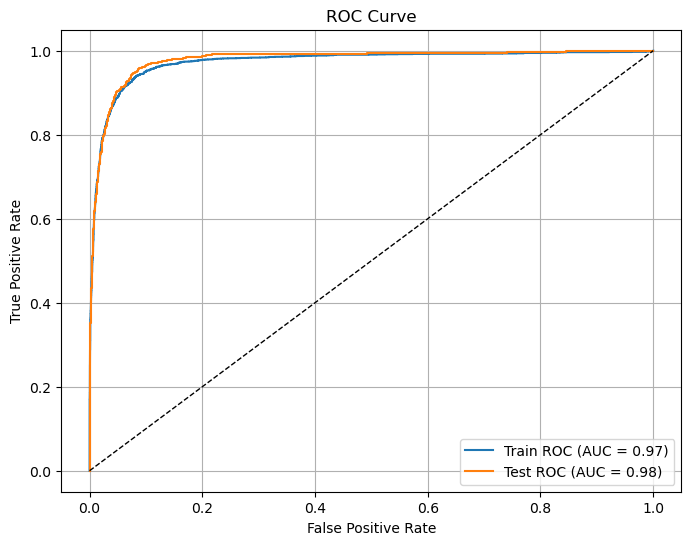

In [119]:
# ROC curve plot
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.savefig(os.path.join(figures_path, "roc_curve.png"), dpi=150)
plt.show()

---

### Cross-Validation

To ensure model robustness, we perform 5-fold cross-validation, reporting the mean and standard deviation of the AUC across folds.

---

In [120]:
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced', random_state=42, solver='liblinear'
    )
)
cv_scores = cross_val_score(
    pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"AUC-ROC per fold: {cv_scores}")
print(f"Mean AUC-ROC (CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

AUC-ROC per fold: [0.97498009 0.97358488 0.97556415 0.9715315  0.97585315]
Mean AUC-ROC (CV): 0.974 ± 0.002


---
## 6. Robustness Checks (Sanity Checks)

We test the model using synthetic companies with extreme ratios (“very healthy” and “bankrupt”) to confirm it responds coherently. This builds confidence in the model’s output for real-world cases.

---

In [121]:
# Sanity check: extremely healthy company
healthy = pd.DataFrame([{
    "X1": 0.8,
    "X2": 0.6,
    "X3": 0.2,
    "X4": 70000,
    "X5": 1.2
}])
healthy_scaled = scaler.transform(healthy)
print("Distress probability (very healthy):", logit.predict_proba(healthy_scaled)[:,1])

# Sanity check: bankrupt company
bankrupt = pd.DataFrame([{
    "X1": -1.2,
    "X2": -2.2,
    "X3": -0.5,
    "X4": 20,
    "X5": 0.02
}])
bankrupt_scaled = scaler.transform(bankrupt)
print("Distress probability (bankrupt):", logit.predict_proba(bankrupt_scaled)[:,1])

Distress probability (very healthy): [0.00031879]
Distress probability (bankrupt): [0.99998792]


---

## 7. Model, Scaler, and Results Export

The trained model and scaler are saved as `.pkl` files for future scoring. Predicted probabilities and classes for all companies are exported to enable portfolio-level reporting and consulting.

---

In [122]:
import joblib

# Export trained model and scaler
joblib.dump(logit, "../outputs/modelo_zlogit.pkl")
joblib.dump(scaler, "../outputs/escalador_zlogit.pkl")

# Predict and export probabilities and class for all companies
df_model["proba_distress"] = logit.predict_proba(scaler.transform(df_model[["X1", "X2", "X3", "X4", "X5"]]))[:, 1]
df_model["pred_clase"] = logit.predict(scaler.transform(df_model[["X1", "X2", "X3", "X4", "X5"]]))
df_model.to_csv("../outputs/zscore_modelo_resultados.csv", index=False)

---

## 8. Segment Diagnostics and Visualization

We analyze the distribution of distress probabilities by industry and geography. This allows for more relevant, defendable benchmarks and segment-adjusted risk thresholds.

---

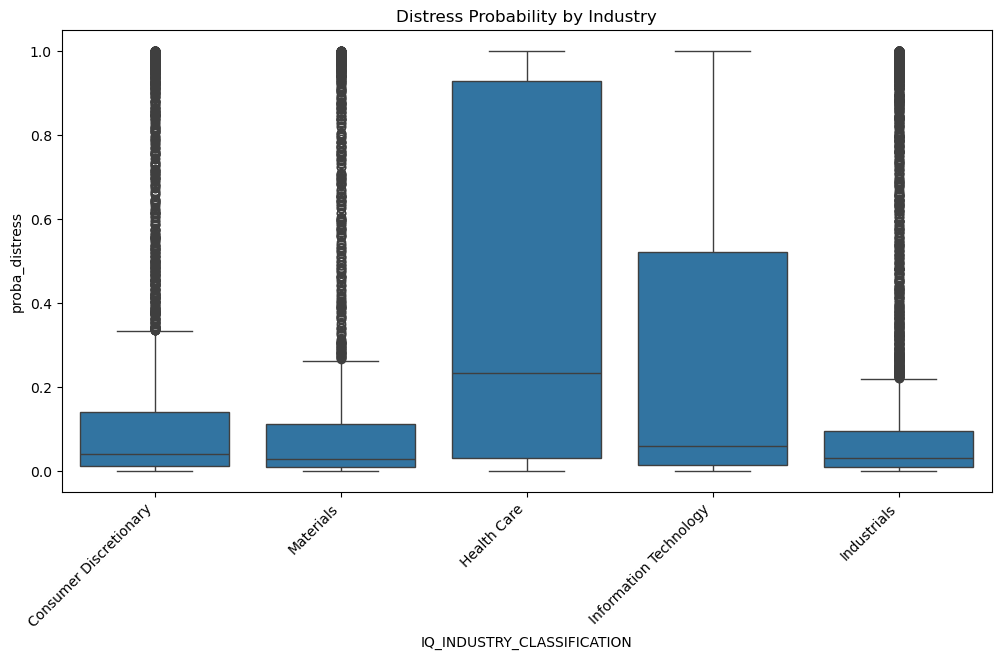

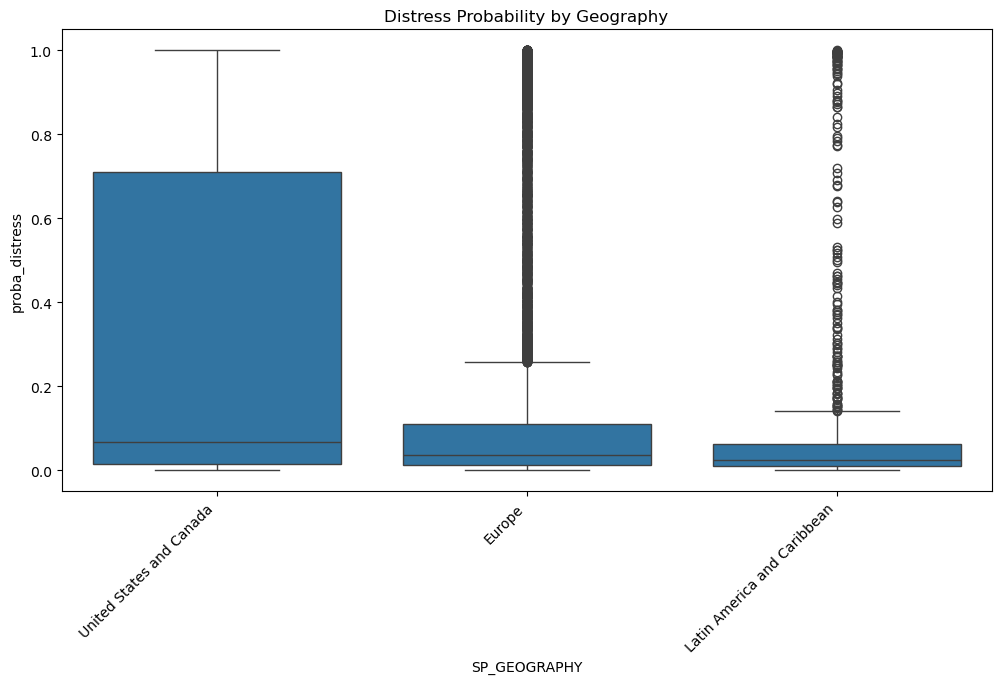

In [123]:
# By industry
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model, x="IQ_INDUSTRY_CLASSIFICATION", y="proba_distress")
plt.xticks(rotation=45, ha='right')
plt.title("Distress Probability by Industry")
plt.savefig(os.path.join(figures_path, "probdistress_by_industry.png"), dpi=150)
plt.show()

# By geography
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model, x="SP_GEOGRAPHY", y="proba_distress")
plt.xticks(rotation=45, ha='right')
plt.title("Distress Probability by Geography")
plt.savefig(os.path.join(figures_path, "probdistress_by_geography.png"), dpi=150)
plt.show()

---

## 9. Segment-Specific Percentiles (Benchmarking)

To provide defendable, segment-specific benchmarking, we compute the internal percentiles (P10, P25, Median, P75, P90) of `proba_distress` for each industry and country. This approach, following Altman (2016) and Barboza (2017), avoids arbitrary universal cutoffs and enables tailored risk recommendations.

---

In [124]:
# Calculate industry percentiles
percentiles = [0.10, 0.25, 0.5, 0.75, 0.90]
industry_percentiles = (
    df_model.groupby("IQ_INDUSTRY_CLASSIFICATION")["proba_distress"]
    .quantile(percentiles)
    .unstack(level=-1)
    .reset_index()
)
industry_percentiles.columns = ["Industry", "P10", "P25", "Median", "P75", "P90"]
industry_percentiles = industry_percentiles.sort_values("Median", ascending=False)
print(industry_percentiles)

                 Industry       P10       P25    Median       P75       P90
1             Health Care  0.006653  0.032010  0.234848  0.929115  0.983533
3  Information Technology  0.003885  0.014085  0.060226  0.521416  0.974455
0  Consumer Discretionary  0.003384  0.011915  0.041417  0.141190  0.711903
2             Industrials  0.004046  0.011350  0.031915  0.095115  0.696388
4               Materials  0.003793  0.010489  0.028678  0.111825  0.803068


In [125]:
# Calculate geography percentiles
geo_percentiles = (
    df_model.groupby("SP_GEOGRAPHY")["proba_distress"]
    .quantile(percentiles)
    .unstack(level=-1)
    .reset_index()
)
geo_percentiles.columns = ["Geography", "P10", "P25", "Median", "P75", "P90"]
print(geo_percentiles)

                     Geography       P10       P25    Median       P75  \
0                       Europe  0.004350  0.012262  0.036304  0.110655   
1  Latin America and Caribbean  0.004422  0.010352  0.025207  0.062729   
2     United States and Canada  0.004088  0.015141  0.068376  0.709579   

        P90  
0  0.655070  
1  0.285328  
2  0.978523  


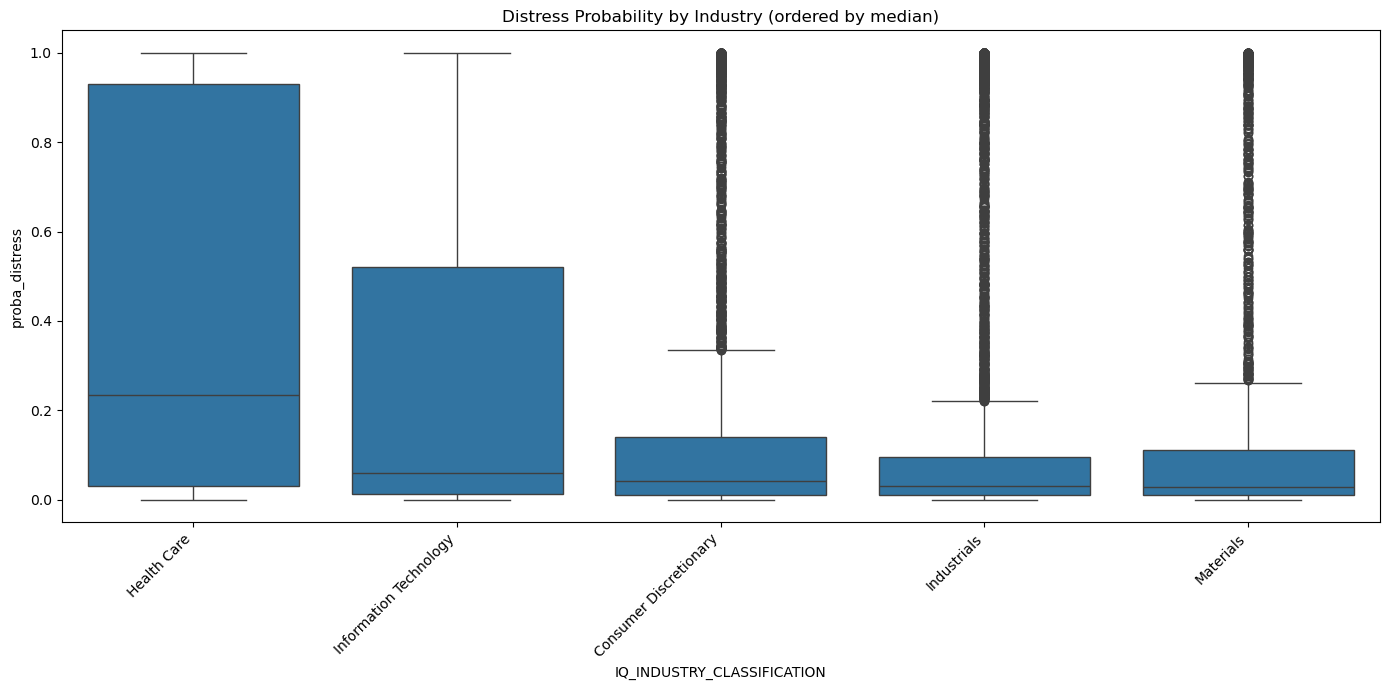

In [126]:
# Visualize boxplots ordered by median industry risk
plt.figure(figsize=(14, 7))
order = industry_percentiles.sort_values("Median", ascending=False)["Industry"]
sns.boxplot(data=df_model, x="IQ_INDUSTRY_CLASSIFICATION", y="proba_distress", order=order)
plt.xticks(rotation=45, ha='right')
plt.title("Distress Probability by Industry (ordered by median)")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "distress_proba_industry_ordered.png"), dpi=150)
plt.show()

## 10. Relative Risk by Sector and Estimated Rating

With each company’s distress probability, we assign a **relative risk category** (“Low”, “Medium”, “High risk”) based on its industry percentiles (Altman 2016 best practices):

- **Low risk:** Distress probability < median of its industry.
- **Medium risk:** Between the median and the 90th percentile (P90) of its industry.
- **High risk:** ≥ 90th percentile (the riskiest 10%).

This enables peer-to-peer risk interpretation, avoiding bias from universal cutoffs.

Additionally, we estimate an **equivalent credit rating** using Altman’s (2016) reference table mapping distress probability to S&P/Moody’s-like categories (AAA/AA, A, BBB, BB, B, CCC/D). This is a consulting reference, **not an official rating**.

> **Note:** Percentiles and ratings are based on the current dataset. Update these regularly to keep benchmarks relevant.

The final file is ready for dashboards, reporting and portfolio analysis.

In [127]:
# Step 1: Merge industry percentiles with each company
df_equiv = df_model.merge(
    industry_percentiles,  # from previous percentiles block
    left_on="IQ_INDUSTRY_CLASSIFICATION", right_on="Industry", how="left"
)

# Step 2: Assign relative risk category by sector
df_equiv["risk_category"] = df_equiv.apply(categorizar_riesgo_sector, axis=1)

# Step 3: Assign “estimated rating” (Altman 2016 mapping)
df_equiv["estimated_rating"] = df_equiv["proba_distress"].apply(rating_altman)

# Short summary for review
print(df_equiv[["IQ_INDUSTRY_CLASSIFICATION", "proba_distress", "risk_category", "estimated_rating"]].head())
print(df_equiv["risk_category"].value_counts())
print(df_equiv["estimated_rating"].value_counts())

  IQ_INDUSTRY_CLASSIFICATION  proba_distress risk_category estimated_rating
0     Consumer Discretionary        0.021387      Low risk                A
1                  Materials        0.970726     High risk            CCC/D
2                Health Care        0.363174   Medium risk            CCC/D
3     Information Technology        0.954983   Medium risk            CCC/D
4     Consumer Discretionary        0.396033   Medium risk            CCC/D
risk_category
Low risk       11855
Medium risk     9485
High risk       2373
Name: count, dtype: int64
estimated_rating
AAA/AA    7666
CCC/D     6198
A         3431
BBB       3283
BB        1827
B         1308
Name: count, dtype: int64


In [130]:
# Resumen visual y conteos
print(df_equiv[[
    "IQ_INDUSTRY_CLASSIFICATION", "proba_distress", "risk_category", "estimated_rating"
]].head())

print(df_equiv["risk_category"].value_counts())
print(df_equiv["estimated_rating"].value_counts())

  IQ_INDUSTRY_CLASSIFICATION  proba_distress risk_category estimated_rating
0     Consumer Discretionary        0.021387      Low risk                A
1                  Materials        0.970726     High risk            CCC/D
2                Health Care        0.363174   Medium risk            CCC/D
3     Information Technology        0.954983   Medium risk            CCC/D
4     Consumer Discretionary        0.396033   Medium risk            CCC/D
risk_category
Low risk       11855
Medium risk     9485
High risk       2373
Name: count, dtype: int64
estimated_rating
AAA/AA    7666
CCC/D     6198
A         3431
BBB       3283
BB        1827
B         1308
Name: count, dtype: int64


In [131]:
# Step 4: Calculate company’s percentile within its industry
df_equiv['industry_percentile'] = (
    df_equiv.groupby('IQ_INDUSTRY_CLASSIFICATION')['proba_distress']
    .rank(pct=True)
)

# Final export for dashboards/reporting
df_equiv.to_csv("../outputs/zscore_modelo_riesgo_dashboard.csv", index=False)